In [122]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
import importlib
import torch
import model.transformer
import model.data as data
import model.constants as constants
import time
import matplotlib.pyplot as plt
from IPython.display import display
importlib.reload(constants)
importlib.reload(model.transformer)
importlib.reload(data)
print("START: ", time.perf_counter())
if constants.DEBUG: print("Start of file", time.perf_counter())
transformer = model.transformer.Transformer()
if constants.DEBUG: print("Transform made", time.perf_counter())
dev_cutoff = int(0.9 * len(data.full_text)) # TODO add test split
train_data = data.full_text[:dev_cutoff]
dev_data = data.full_text[dev_cutoff:]
X_batch, Y_batch = data.GetRandomBatch(train_data)

START:  81442.740712916


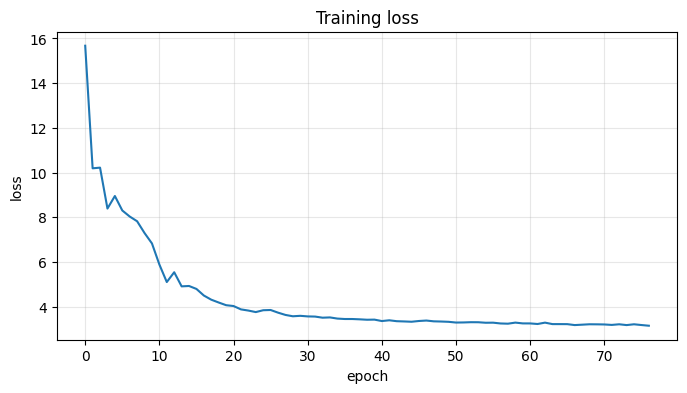

loss: 15.676103591918945
loss: 10.192956924438477
loss: 10.22327995300293
loss: 8.393062591552734
loss: 8.954606056213379
loss: 8.30718994140625
loss: 8.03683853149414
loss: 7.82493257522583
loss: 7.298308849334717
loss: 6.83349609375
loss: 5.891395092010498
loss: 5.106260299682617
loss: 5.544514179229736
loss: 4.91346549987793
loss: 4.930022716522217
loss: 4.797944068908691
loss: 4.50290060043335
loss: 4.316882133483887
loss: 4.190526008605957
loss: 4.071005344390869
loss: 4.033743858337402
loss: 3.8834383487701416
loss: 3.830944061279297
loss: 3.7629904747009277
loss: 3.845552682876587
loss: 3.856257438659668
loss: 3.7377219200134277
loss: 3.635592222213745
loss: 3.575521945953369
loss: 3.59566068649292
loss: 3.5697226524353027
loss: 3.5619492530822754
loss: 3.5121188163757324
loss: 3.5243825912475586
loss: 3.4725074768066406
loss: 3.4530932903289795
loss: 3.453115701675415
loss: 3.4391095638275146
loss: 3.4205822944641113
loss: 3.4259023666381836
loss: 3.3619494438171387
loss: 3.395

KeyboardInterrupt: 

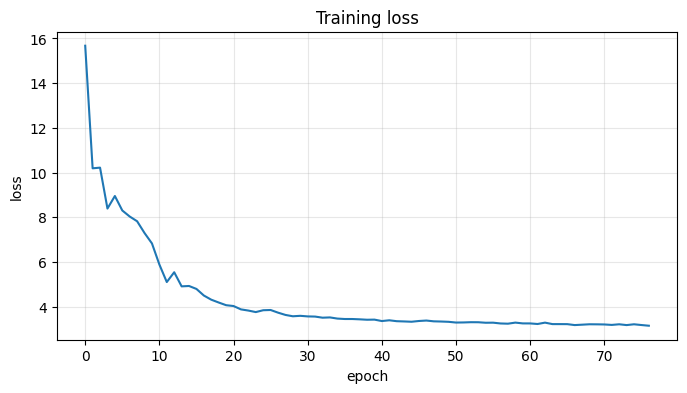

In [124]:

loss_steps = []
loss_history = []
plot_every = 1

fig, ax = plt.subplots(figsize=(8, 4))
(loss_line,) = ax.plot([], [])
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training loss")
ax.grid(True, alpha=0.3)
plot_handle = display(fig, display_id=True)

for i in range(constants.EPOCHS):
    if constants.DEBUG: print("Start", time.perf_counter())
    X_batch, Y_batch = data.GetRandomBatch(train_data);
    if constants.DEBUG: print("Got batches", time.perf_counter())
    out = transformer.forward(X_batch)
    if constants.DEBUG: print("Forwad complete", time.perf_counter())
    B, T, C = out.shape
    loss = transformer.backward(out.view(B*T, C), Y_batch.view(B*T))
    if constants.DEBUG: print("Backward complete", time.perf_counter())
    if (i % plot_every == 0) or (i == constants.EPOCHS - 1):
        print(f"loss: {loss}")
        loss_steps.append(i)
        loss_history.append(loss)
        loss_line.set_data(loss_steps, loss_history)
        ax.relim()
        ax.autoscale_view()
        if plot_handle is not None:
            plot_handle.update(fig)
        else:
            fig.canvas.draw_idle()
            plt.pause(0.001)

plt.close(fig)

In [125]:
def DecodeTokenList(token_list):
    return data.decode(token_list)


def TestModel(transformer, data_source, n_tokens=10):
    X_test, _ = data.GetRandomBatch(data_source)
    # X_test = X_batch
    context = X_test[0].clone()
    start_context = context.clone()

    print("START:")
    print(DecodeTokenList(context))

    generated_tokens = []

    for i in range(n_tokens):
        # Add fake batch dimension: [T] -> [1, T]
        context_batch = context.view(1, constants.CONTEXT_WINDOW_SIZE)

        # Your transformer currently expects BATCH_SIZE exactly,
        # so repeat the same context BATCH_SIZE times.
        context_batch = context_batch.repeat(constants.BATCH_SIZE, 1)

        # Predict next token from the final position in the first batch row
        with torch.no_grad():
            logits = transformer.forward(context_batch)
        pred = logits[0, -1].argmax(dim=-1)

        generated_tokens.append(pred)

        # Slide context window left and append prediction
        context = torch.cat([context[1:], pred.view(1)], dim=0)

    print("\nGENERATED:")
    print(DecodeTokenList(generated_tokens))

    print("\nFULL:")
    print(DecodeTokenList(start_context) + DecodeTokenList(generated_tokens))

TestModel(transformer, train_data, n_tokens=10)

START:
or I have bought it with an hundred blows.
But let me see: is this our foeman's face?
Ah, no, no, no, it is mine only son!
Ah, boy, if any life be left in thee,
Throw up thine eye! see, see what showers arise,
Blown with the windy tempest of my heart,
Upon

GENERATED:
 t t t t t

FULL:
or I have bought it with an hundred blows.
But let me see: is this our foeman's face?
Ah, no, no, no, it is mine only son!
Ah, boy, if any life be left in thee,
Throw up thine eye! see, see what showers arise,
Blown with the windy tempest of my heart,
Upon t t t t t


In [ ]:
def ModelContextWindowSize(transformer):
    return transformer.positional_encoding.shape[0]


def EncodeFixedContext(text, context_window_size):
    tokens = data.encode(text)
    if len(tokens) < context_window_size:
        pad_token = data.tokenizer_map[' ']
        tokens = [pad_token] * (context_window_size - len(tokens)) + tokens
    else:
        tokens = tokens[-context_window_size:]
    return torch.tensor(tokens, dtype=torch.int64, device=model.shared.device)


@torch.no_grad()
def ForwardSingleContext(transformer, context_tokens):
    context_window_size = ModelContextWindowSize(transformer)
    context_batch = context_tokens.view(1, context_window_size)
    context_batch = context_batch.repeat(constants.BATCH_SIZE, 1)

    old_context_window_size = constants.CONTEXT_WINDOW_SIZE
    constants.CONTEXT_WINDOW_SIZE = context_window_size
    try:
        logits = transformer.forward(context_batch)
    finally:
        constants.CONTEXT_WINDOW_SIZE = old_context_window_size

    return logits[0, -1, :]


def ShowTopProbs(name, probs, top_k):
    values, indices = probs.topk(top_k)
    print(name)
    for value, index in zip(values, indices):
        ch = data.untokenizer_map[int(index)]
        print(f"  {repr(ch):>6}  {float(value):.4f}")


def CompareContexts(transformer, text1, text2, top_k=10):
    context_window_size = ModelContextWindowSize(transformer)
    ctx1 = EncodeFixedContext(text1, context_window_size)
    ctx2 = EncodeFixedContext(text2, context_window_size)

    logits1 = ForwardSingleContext(transformer, ctx1)
    logits2 = ForwardSingleContext(transformer, ctx2)

    probs1 = torch.softmax(logits1, dim=-1)
    probs2 = torch.softmax(logits2, dim=-1)

    print("CTX 1:", repr(data.decode(ctx1)))
    print("CTX 2:", repr(data.decode(ctx2)))
    print()
    print("max abs logit diff:", (logits1 - logits2).abs().max().item())
    print("mean abs logit diff:", (logits1 - logits2).abs().mean().item())
    print("max abs prob diff:", (probs1 - probs2).abs().max().item())
    print()

    ShowTopProbs("top ctx1:", probs1, top_k)
    print()
    ShowTopProbs("top ctx2:", probs2, top_k)


CompareContexts(
    transformer,
    "To be, or not to be, that is",
    "zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz",
)

CompareContexts(
    transformer,
    "wel in a ten-times-barr'd-up che",
    "xxxxxxxxxxxxxxxxxxxxxxxxxxxxx che",
)

CompareContexts(
    transformer,
    "aaaaaaaaaaaaaaaaaaaaaaaaaaaa the ",
    "bbbbbbbbbbbbbbbbbbbbbbbbbbbb the ",
)


CTX 1: '    To be, or not to be, that is'
CTX 2: 'zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz'

max abs logit diff: 25.632192611694336
mean abs logit diff: 7.0928053855896
max abs prob diff: 0.8826323747634888

top ctx1:
     ' '  0.8898
    '\n'  0.0293
     's'  0.0244
     ','  0.0206
     '.'  0.0076
     ':'  0.0060
     't'  0.0057
     "'"  0.0040
     ';'  0.0023
     '?'  0.0014

top ctx2:
     'e'  0.6839
     'i'  0.1469
     'a'  0.0511
     'o'  0.0327
     'n'  0.0214
     'y'  0.0187
     'u'  0.0174
     ':'  0.0078
     ' '  0.0071
     's'  0.0032
CTX 1: "wel in a ten-times-barr'd-up che"
CTX 2: 'xxxxxxxxxxxxxxxxxxxxxxxxxxxx che'

max abs logit diff: 1.5921783447265625
mean abs logit diff: 0.42408299446105957
max abs prob diff: 0.19279856979846954

top ctx1:
     'a'  0.2849
     'e'  0.2444
     'r'  0.0936
     's'  0.0583
     'm'  0.0526
     'n'  0.0444
     ' '  0.0405
     'i'  0.0343
     'l'  0.0311
     'q'  0.0207

top ctx2:
     'e'  0.4372
     'a'  0.2324
     'r' 